In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


import library

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data

In [4]:
from PIL import Image
import torchvision.transforms as transforms

imsize = 256

img_transforms = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor(), # To (CxHxW) and scale 0-1
])

In [6]:
def image_loader(image_name):
    image = Image.open(image_name)
    image = img_transforms(image).unsqueeze(0)
    return image.to(device, torch.float)

style_img_1 = image_loader ("/content/drive/MyDrive/AIO_2024/Module9/NST_imgs/Background1.jpg")
style_img_2 = image_loader ("/content/drive/MyDrive/AIO_2024/Module9/NST_imgs/Background2.jpg")
content_img = image_loader("/content/drive/MyDrive/AIO_2024/Module9/NST_imgs/Cat.jpg")

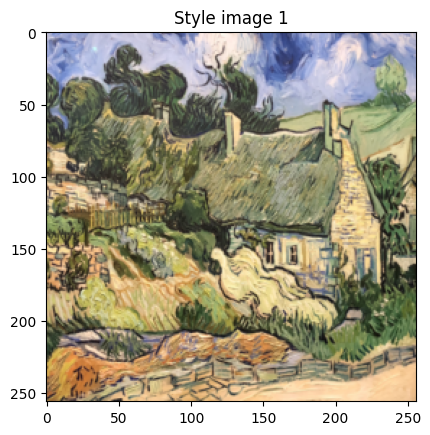

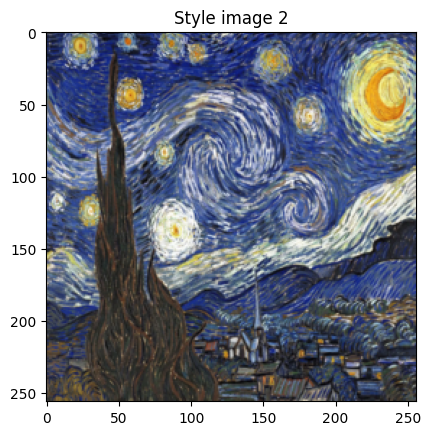

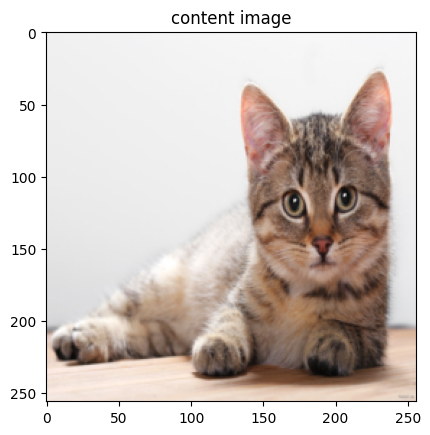

In [7]:
unloader = transforms.ToPILImage()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)

plt.figure()
imshow(style_img_1, title="Style image 1")

plt.figure()
imshow(style_img_2, title="Style image 2")

plt.figure()
imshow(content_img, title="content image")

# loss function

## content loss

In [9]:
content_weight = 1e1
ContentLoss = nn.MSELoss()

## Style loss

In [10]:
def gram_matrix(tensor):
    a, b, c, d = tensor.size()
    tensor = tensor.view(a*b, c*d)
    G = torch.mm(tensor, tensor.t())
    return G.div(a*b*c*d)

style_weight = 1e7
StyleLoss = nn.MSELoss()

# model

In [11]:
from torchvision.models import vgg16, VGG16_Weights

VGG16_pretrained = vgg16(weights=VGG16_Weights.DEFAULT).features.eval()

for param in VGG16_pretrained.parameters():
    param.requires_grad_(False)

VGG16_pretrained.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:05<00:00, 104MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [12]:
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

In [13]:
def get_features(pretrained_model, image):
    layers = {
        '0': 'conv_1',
        '5': 'conv_2',
        '10': 'conv_3',
        '19': 'conv_4',
        '28': 'conv_5'
    }
    features = {}
    x = image
    for name, pretrained_layer in pretrained_model._modules.items():
        x = pretrained_layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

In [14]:
content_features = get_features(VGG16_pretrained, content_img)
style_features_1 = get_features(VGG16_pretrained, style_img_1)
style_features_2 = get_features(VGG16_pretrained, style_img_2)


# Train

In [15]:
import torch.optim as optim

target_img = content_img.clone().requires_grad_(True).to(device)
optimizer = optim.Adam([target_img], lr=0.02)

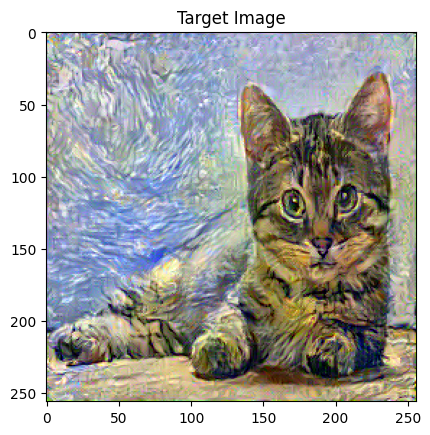

Epoch [100/6000] Total loss: 53.954010 - Content loss: 0.801376 - Style loss: 0.000002
Epoch [200/6000] Total loss: 53.800316 - Content loss: 0.806057 - Style loss: 0.000002


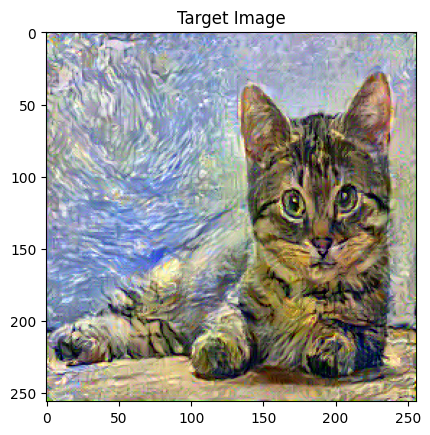

Epoch [300/6000] Total loss: 53.811798 - Content loss: 0.819406 - Style loss: 0.000002
Epoch [400/6000] Total loss: 53.774002 - Content loss: 0.808150 - Style loss: 0.000002
Epoch [500/6000] Total loss: 54.379128 - Content loss: 0.852020 - Style loss: 0.000002
Epoch [600/6000] Total loss: 53.893257 - Content loss: 0.790032 - Style loss: 0.000002
Epoch [700/6000] Total loss: 53.745266 - Content loss: 0.799627 - Style loss: 0.000002


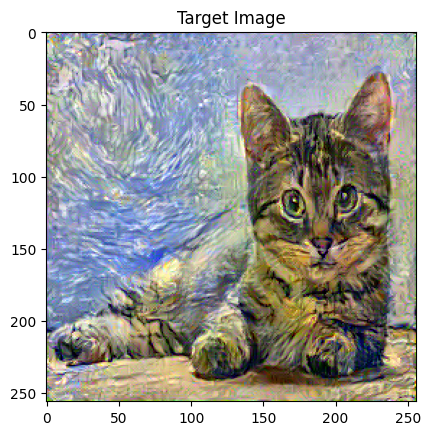

Epoch [800/6000] Total loss: 53.817474 - Content loss: 0.800670 - Style loss: 0.000002
Epoch [900/6000] Total loss: 53.917183 - Content loss: 0.824571 - Style loss: 0.000002
Epoch [1000/6000] Total loss: 53.931160 - Content loss: 0.789216 - Style loss: 0.000002
Epoch [1100/6000] Total loss: 54.015007 - Content loss: 0.778987 - Style loss: 0.000002
Epoch [1200/6000] Total loss: 53.712822 - Content loss: 0.793449 - Style loss: 0.000002


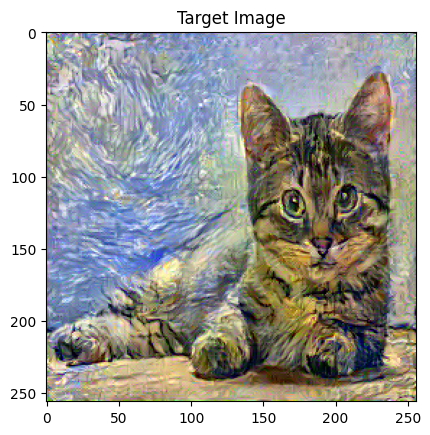

Epoch [1300/6000] Total loss: 63.694069 - Content loss: 1.219994 - Style loss: 0.000002
Epoch [1400/6000] Total loss: 54.101173 - Content loss: 0.824740 - Style loss: 0.000002
Epoch [1500/6000] Total loss: 53.924541 - Content loss: 0.827728 - Style loss: 0.000002
Epoch [1600/6000] Total loss: 53.805748 - Content loss: 0.805287 - Style loss: 0.000002
Epoch [1700/6000] Total loss: 53.794434 - Content loss: 0.805430 - Style loss: 0.000002


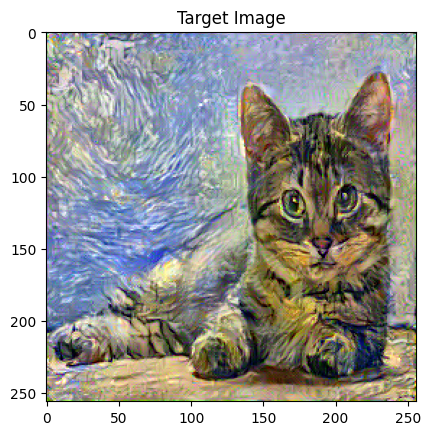

Epoch [1800/6000] Total loss: 53.728901 - Content loss: 0.811572 - Style loss: 0.000002
Epoch [1900/6000] Total loss: 53.899277 - Content loss: 0.831492 - Style loss: 0.000002
Epoch [2000/6000] Total loss: 53.720818 - Content loss: 0.798357 - Style loss: 0.000002
Epoch [2100/6000] Total loss: 53.800812 - Content loss: 0.804226 - Style loss: 0.000002
Epoch [2200/6000] Total loss: 53.763279 - Content loss: 0.814616 - Style loss: 0.000002


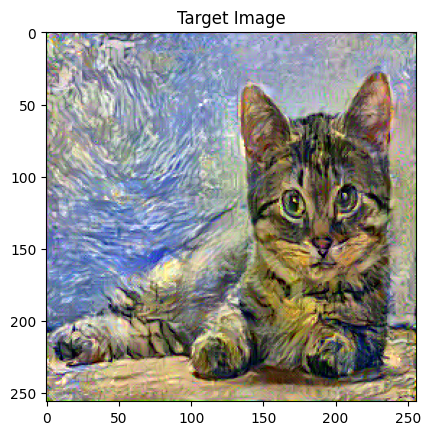

Epoch [2300/6000] Total loss: 54.037346 - Content loss: 0.782483 - Style loss: 0.000002
Epoch [2400/6000] Total loss: 53.684570 - Content loss: 0.795475 - Style loss: 0.000002
Epoch [2500/6000] Total loss: 54.256538 - Content loss: 0.791084 - Style loss: 0.000002
Epoch [2600/6000] Total loss: 53.645096 - Content loss: 0.802814 - Style loss: 0.000002
Epoch [2700/6000] Total loss: 53.633636 - Content loss: 0.791388 - Style loss: 0.000002


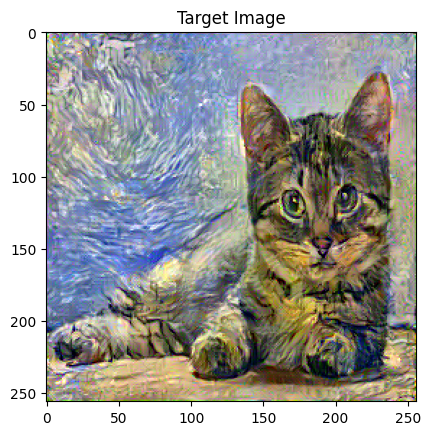

Epoch [2800/6000] Total loss: 53.636993 - Content loss: 0.797328 - Style loss: 0.000002
Epoch [2900/6000] Total loss: 53.945621 - Content loss: 0.781653 - Style loss: 0.000002
Epoch [3000/6000] Total loss: 55.174866 - Content loss: 0.886496 - Style loss: 0.000002
Epoch [3100/6000] Total loss: 53.742989 - Content loss: 0.800153 - Style loss: 0.000002
Epoch [3200/6000] Total loss: 53.693249 - Content loss: 0.812615 - Style loss: 0.000002


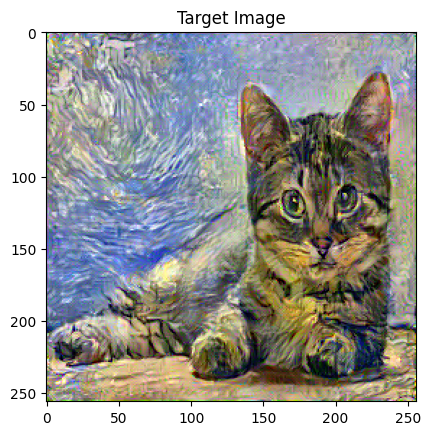

Epoch [3300/6000] Total loss: 53.629349 - Content loss: 0.796641 - Style loss: 0.000002
Epoch [3400/6000] Total loss: 53.810890 - Content loss: 0.823683 - Style loss: 0.000002
Epoch [3500/6000] Total loss: 53.635048 - Content loss: 0.785296 - Style loss: 0.000002
Epoch [3600/6000] Total loss: 53.938560 - Content loss: 0.765603 - Style loss: 0.000002
Epoch [3700/6000] Total loss: 53.581860 - Content loss: 0.787186 - Style loss: 0.000002


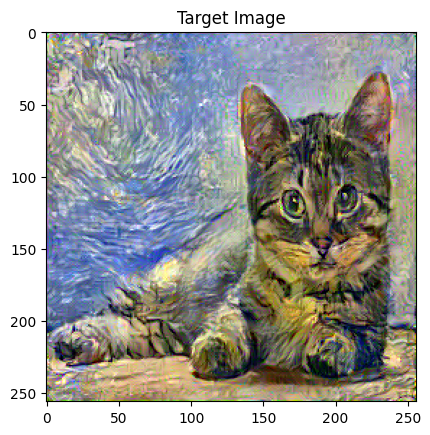

Epoch [3800/6000] Total loss: 53.637756 - Content loss: 0.789045 - Style loss: 0.000002
Epoch [3900/6000] Total loss: 53.605553 - Content loss: 0.802741 - Style loss: 0.000002
Epoch [4000/6000] Total loss: 54.445351 - Content loss: 0.846153 - Style loss: 0.000002
Epoch [4100/6000] Total loss: 53.612930 - Content loss: 0.786868 - Style loss: 0.000002
Epoch [4200/6000] Total loss: 53.548271 - Content loss: 0.786991 - Style loss: 0.000002


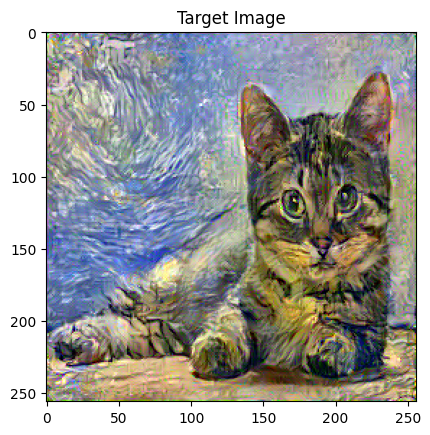

Epoch [4300/6000] Total loss: 53.617191 - Content loss: 0.795894 - Style loss: 0.000002
Epoch [4400/6000] Total loss: 53.804810 - Content loss: 0.770138 - Style loss: 0.000002
Epoch [4500/6000] Total loss: 54.195602 - Content loss: 0.832739 - Style loss: 0.000002
Epoch [4600/6000] Total loss: 53.570599 - Content loss: 0.792477 - Style loss: 0.000002
Epoch [4700/6000] Total loss: 53.546967 - Content loss: 0.779404 - Style loss: 0.000002


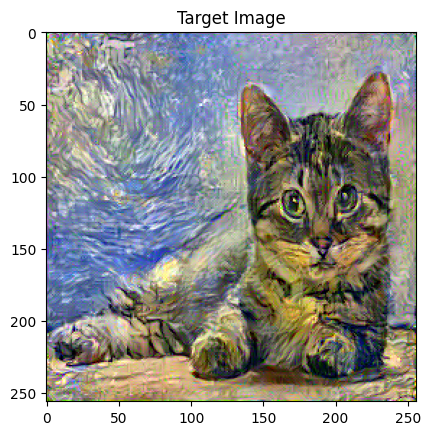

Epoch [4800/6000] Total loss: 53.525307 - Content loss: 0.781436 - Style loss: 0.000002
Epoch [4900/6000] Total loss: 53.715561 - Content loss: 0.772294 - Style loss: 0.000002
Epoch [5000/6000] Total loss: 53.899330 - Content loss: 0.817257 - Style loss: 0.000002
Epoch [5100/6000] Total loss: 53.533375 - Content loss: 0.789346 - Style loss: 0.000002
Epoch [5200/6000] Total loss: 53.538933 - Content loss: 0.801188 - Style loss: 0.000002


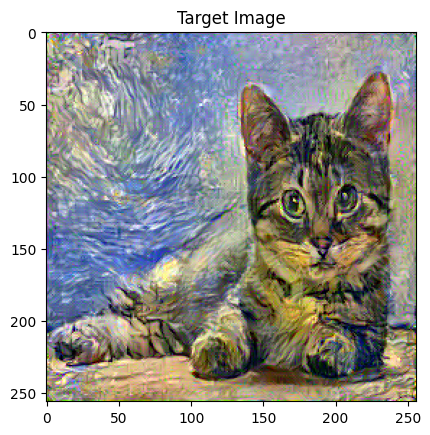

Epoch [5300/6000] Total loss: 53.857132 - Content loss: 0.818364 - Style loss: 0.000002
Epoch [5400/6000] Total loss: 55.409538 - Content loss: 0.887725 - Style loss: 0.000002
Epoch [5500/6000] Total loss: 53.930473 - Content loss: 0.830670 - Style loss: 0.000002


In [ ]:
STEPS = 6000

hist = {
    'style_loss_1': [],
    'style_loss_2': [],
    'content_loss': [],
    'total_loss': []
}

for step in range(STEPS):
    optimizer.zero_grad()
    with torch.no_grad():
        target_img.clamp_(0, 1)
    target_features = get_features(VGG16_pretrained, target_img)

    content_loss = ContentLoss(content_features['conv_4'], target_features['conv_4'])

    style_loss_1 = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = gram_matrix(style_features_1[layer])
        style_loss_1 += StyleLoss(style_gram, target_gram)

    style_loss_2 = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = gram_matrix(style_features_2[layer])
        style_loss_2 += StyleLoss(style_gram, target_gram)

    total_loss = content_loss*content_weight + style_loss_1*style_weight + style_loss_2*style_weight
    hist['content_loss'].append(content_loss.item())
    hist['style_loss_1'].append(style_loss_1.item())
    hist['style_loss_2'].append(style_loss_2.item())
    hist['total_loss'].append(total_loss.item())

    total_loss.backward(retain_graph=True)
    optimizer.step()
    if step % 100 == 99:
        print(f"Epoch [{step+1}/{STEPS}] Total loss: {total_loss.item():.6f} - Content loss: {content_loss.item():.6f} - Style loss: {style_loss_1.item():.6f}")

    with torch.no_grad():
        target_img.clamp_(0, 1)

    # save earch 200 steps
    if step % 500 == 199 or step == 0:
        plt.figure()
        imshow(target_img, title='Target Image')
        # plt.savefig(f'/content/drive/MyDrive/AIO_2024/Module9/NST_imgs/output_{step}.png', bbox_inches='tight')
        plt.show()